In [9]:
import numpy as np
import time
import pennylane as qml
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Set global random seed
np.random.seed(42)
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.grid'] = True
plt.style.use('seaborn-v0_8-muted')

In [10]:
#2.Data Loading and Preprocessing
def prepare_data(n_qubits=4, num_samples=800, grid_size=4, noise_std=0.1):
    X = []
    y = []
    # 1. Generate BAS data (1: Bars/horizontal stripes, -1: Stripes/vertical stripes)
    for _ in range(num_samples):
        label = np.random.choice([1, -1])
        img = np.zeros((grid_size, grid_size))
        if label == 1: 
            for i in range(grid_size):
                img[i, :] = np.random.choice([0, 1])
        else:
            for j in range(grid_size):
                img[:, j] = np.random.choice([0, 1])
        X.append(img.flatten())
        y.append(label)
        
    X = np.array(X)
    y = np.array(y)
    
    # 2. Inject additive Gaussian noise simulating real-world conditions (sigma = 0.1)
    X_noisy = X + np.random.normal(0, noise_std, X.shape)
    
    # 3. Data Normalization
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X_noisy)
    
    # 4. PCA dimensionality reduction to target dimension (d = 4)
    pca = PCA(n_components=n_qubits)
    X_pca = pca.fit_transform(X_scaled)
    
    return train_test_split(X_pca, y, test_size=0.2, random_state=42)

In [11]:
# 3.Quantum Model Definition
n_qubits = 4 
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def get_quantum_state(x):
    # Use ZZFeatureMap with 2 repetitions (reps=2)
    for _ in range(2):
        # Linear encoding layer
        for i in range(n_qubits):
            qml.Hadamard(wires=i)
            qml.RZ(2 * x[i], wires=i)
            
        # Entanglement encoding layer 
        for i in range(n_qubits - 1):
            # Entangle only adjacent qubits
            qml.CNOT(wires=[i, i + 1])
            qml.RZ(2 * (np.pi - x[i]) * (np.pi - x[i + 1]), wires=i + 1)
            qml.CNOT(wires=[i, i + 1])
            
    return qml.state()

def compute_quantum_kernel(X_A, X_B):
    # Quickly compute the Fidelity Kernel using the squared modulus of the state vector inner product
    states_A = np.array([get_quantum_state(x) for x in X_A])
    states_B = np.array([get_quantum_state(x) for x in X_B])
    return np.abs(states_A.conj().dot(states_B.T)) ** 2

In [12]:
# 4. Classical Model Definition (RBF Kernel)
def compute_classical_kernel(X_A, X_B, gamma=1.0):
    return rbf_kernel(X_A, X_B, gamma=gamma)

In [13]:
# 5. Unified Training Algorithm (Pegasos Kernel SVM)
class PegasosTrainer:
    def __init__(self, lambda_val=0.01, batch_size=32, epochs=100):
        self.lambda_val = lambda_val
        self.batch_size = batch_size
        self.epochs = epochs
        self.alphas = None
        self.train_y = None
        self.loss_history = []
        self.final_t = 1

    def fit(self, K, y):
        n_samples = K.shape[0]
        self.alphas = np.zeros(n_samples)
        self.train_y = y
        indices = np.arange(n_samples)
        t = 1
        
        for epoch in range(self.epochs):
            np.random.shuffle(indices)
            for i in range(0, n_samples, self.batch_size):
                batch_idx = indices[i : i + self.batch_size]
                if len(batch_idx) == 0:
                    continue
                
                coef = self.alphas * self.train_y
                f_x = (1.0 / (self.lambda_val * t)) * (K[batch_idx, :] @ coef)
                
                # Alpha update logic: find samples that violate the margin
                violations = (y[batch_idx] * f_x) < 1.0
                for idx, is_viol in zip(batch_idx, violations):
                    if is_viol:
                        self.alphas[idx] += 1.0 / len(batch_idx)
                
                # Calculate loss function (Hinge Loss + L2 regularization term)
                f_x_all = (1.0 / (self.lambda_val * t)) * (K @ coef)
                hinge_loss = np.mean(np.maximum(0, 1 - self.train_y * f_x_all))
                reg_term = 0.5 * self.lambda_val * (1.0 / ((self.lambda_val * t) ** 2)) * (coef.T @ K @ coef)
                self.loss_history.append(hinge_loss + reg_term)
                t += 1
                
        self.final_t = t - 1

    def predict_scores(self, K_test):
        coef = self.alphas * self.train_y
        return (1.0 / (self.lambda_val * self.final_t)) * (K_test @ coef)

In [14]:
# 6.Execute Training and Time It
# Get the 4-dimensional reduced and noisy BAS dataset
X_train, X_test, y_train, y_test = prepare_data(n_qubits=n_qubits, num_samples=800)

print(f"==> Generating Data... Train Set: {len(X_train)}, Test Set: {len(X_test)}")

# Quantum model training (Batch size = 32, Epochs = 100)
print(f"==> Training Pegasos-QSVM on {len(X_train)} samples...")
start_q = time.time()
K_train_q = compute_quantum_kernel(X_train, X_train)
qsvm = PegasosTrainer(lambda_val=0.01, batch_size=32, epochs=100)
qsvm.fit(K_train_q, y_train)
q_train_time = time.time() - start_q

# Classical model training (Batch size = 32, Epochs = 100)
print(f"==> Training Pegasos-SVM (Classical) on {len(X_train)} samples...")
start_c = time.time()
K_train_c = compute_classical_kernel(X_train, X_train, gamma=1.0)
svm = PegasosTrainer(lambda_val=0.01, batch_size=32, epochs=100)
svm.fit(K_train_c, y_train)
c_train_time = time.time() - start_c

==> Generating Data... Train Set: 640, Test Set: 160
==> Training Pegasos-QSVM on 640 samples...
==> Training Pegasos-SVM (Classical) on 640 samples...


In [15]:
# 7. Unified Evaluation Function
print("==> Evaluating models...")
def evaluate(model, K_test, y_true):
    start_infer = time.time()
    scores = model.predict_scores(K_test)
    preds = np.sign(scores)
    preds[preds == 0] = 1 
    infer_time = time.time() - start_infer
    
    fpr, tpr, _ = roc_curve(y_true, scores)
    
    return {
        'Accuracy': accuracy_score(y_true, preds),
        'Precision': precision_score(y_true, preds, zero_division=0),
        'Recall': recall_score(y_true, preds, zero_division=0),
        'F1-Score': f1_score(y_true, preds, zero_division=0),
        'AUC-ROC': auc(fpr, tpr),
        'InferTime': infer_time,
        'fpr': fpr, 
        'tpr': tpr
    }

metrics_q = evaluate(qsvm, compute_quantum_kernel(X_test, X_train), y_test)
metrics_c = evaluate(svm, compute_classical_kernel(X_test, X_train), y_test)

metric_keys = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
print("\nFinal Results Summary (with Noise σ=0.1):")
for m in metric_keys:
    print(f"{m:10s} -> Classical SVM: {metrics_c[m]:.4f} | Quantum QSVM: {metrics_q[m]:.4f}")

==> Evaluating models...

Final Results Summary (with Noise σ=0.1):
Accuracy   -> Classical SVM: 0.9563 | Quantum QSVM: 0.9062
Precision  -> Classical SVM: 0.9247 | Quantum QSVM: 0.9610
Recall     -> Classical SVM: 1.0000 | Quantum QSVM: 0.8605
F1-Score   -> Classical SVM: 0.9609 | Quantum QSVM: 0.9080
AUC-ROC    -> Classical SVM: 0.9928 | Quantum QSVM: 0.9486


==> Generating visual analysis...


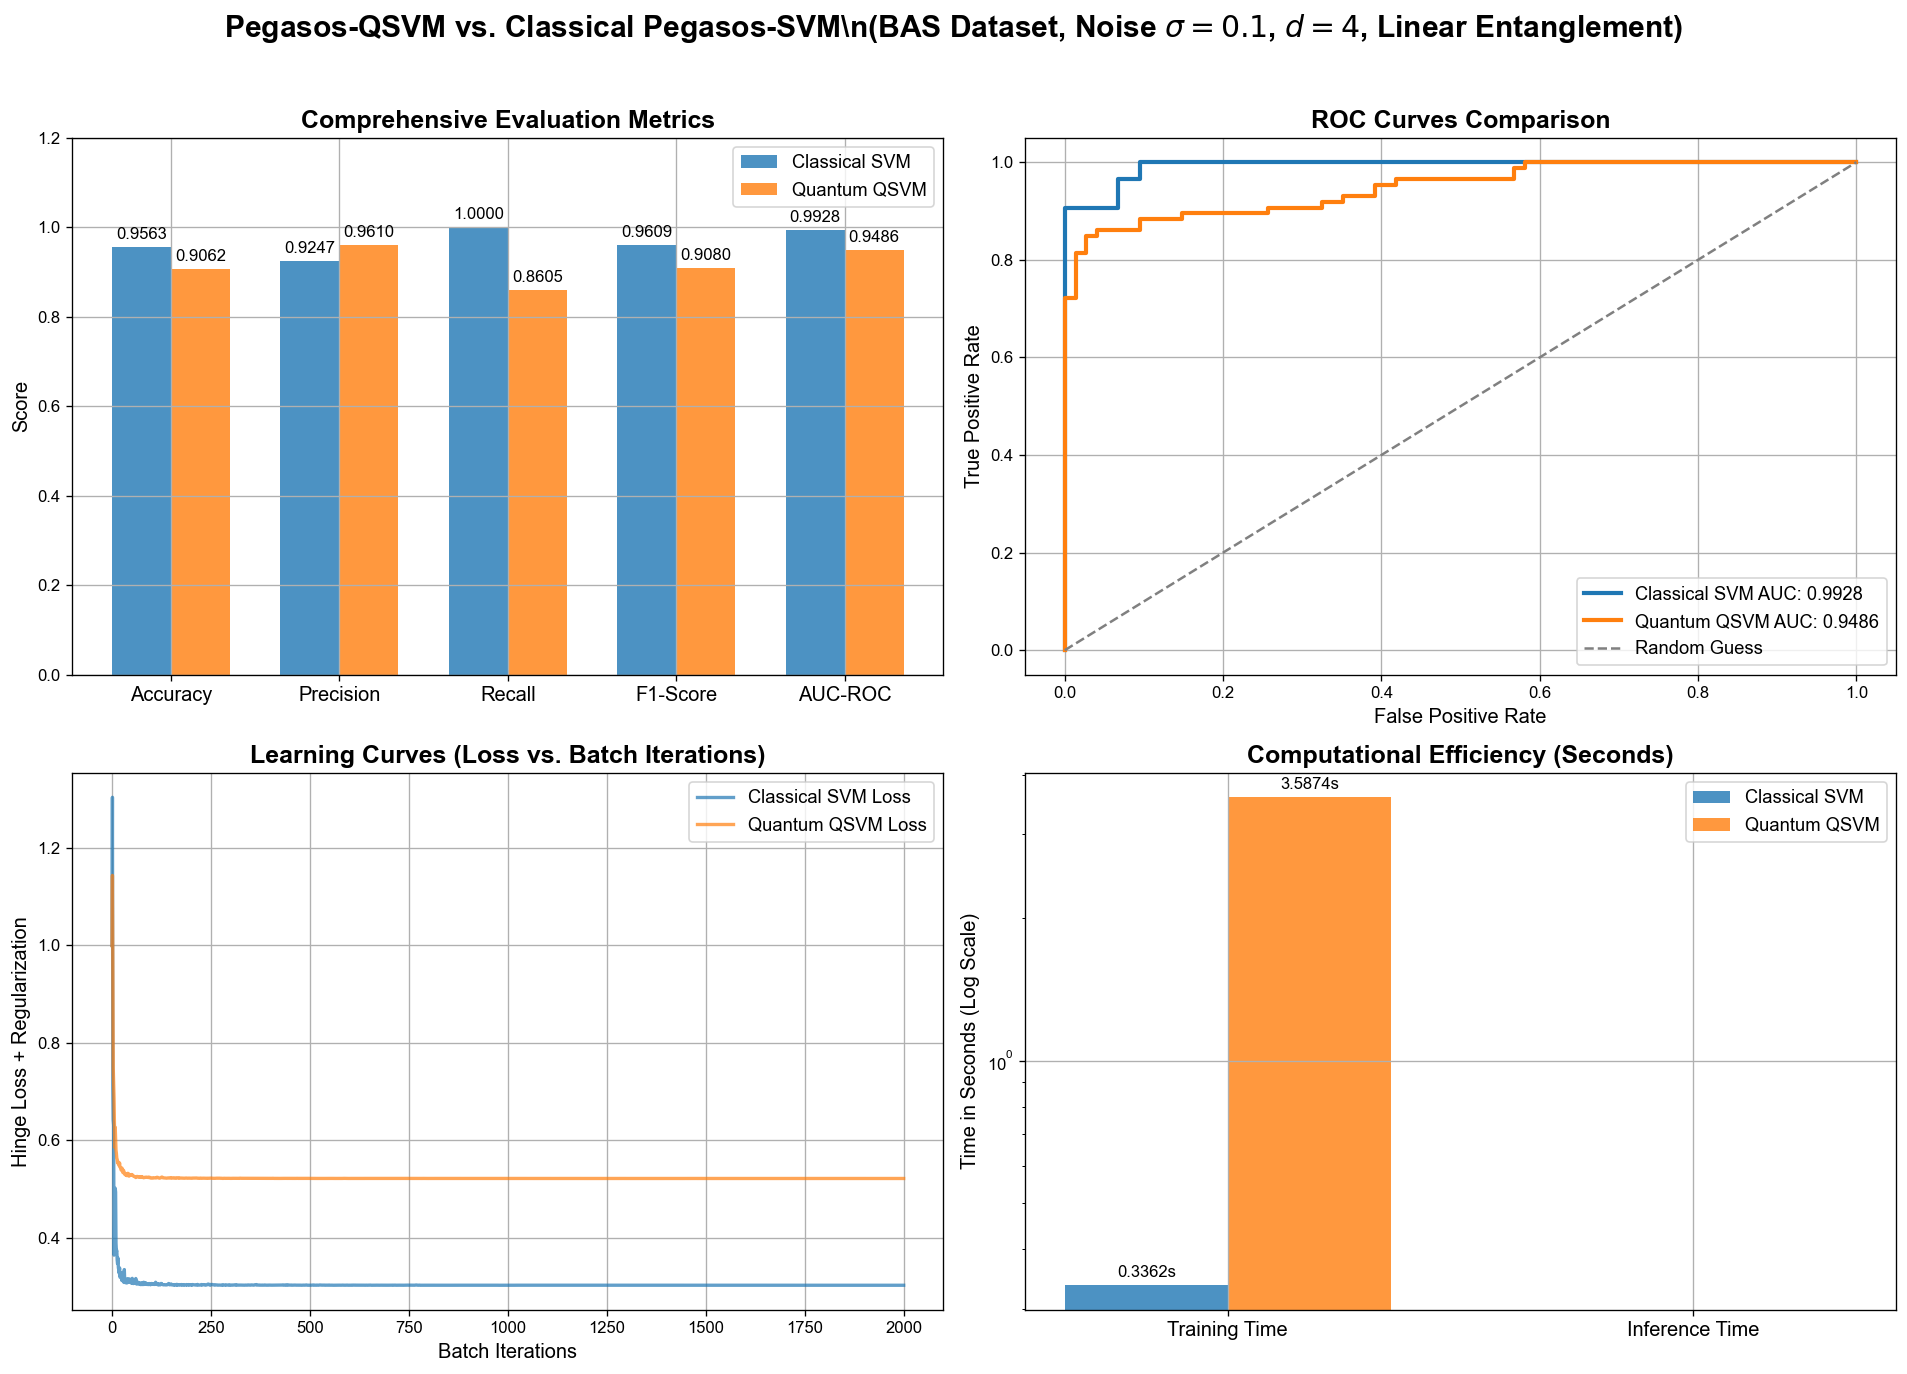

In [17]:
# 8: Result Visualization
print("==> Generating visual analysis...")
fig, axs = plt.subplots(2, 2, figsize=(16, 12), dpi=120)
color_svm = '#1f77b4' 
color_qsvm = '#ff7f0e' 

fig.suptitle(r'Pegasos-QSVM vs. Classical Pegasos-SVM\n(BAS Dataset, Noise $\sigma=0.1$, $d=4$, Linear Entanglement)', 
             fontsize=18, fontweight='bold', y=0.98)

# [Top-Left] Comprehensive Evaluation Metrics
x_metrics = np.arange(len(metric_keys))
width = 0.35
rects1 = axs[0, 0].bar(x_metrics - width/2, [metrics_c[k] for k in metric_keys], width, label='Classical SVM', color=color_svm, alpha=0.8)
rects2 = axs[0, 0].bar(x_metrics + width/2, [metrics_q[k] for k in metric_keys], width, label='Quantum QSVM', color=color_qsvm, alpha=0.8)
axs[0, 0].set_xticks(x_metrics)
axs[0, 0].set_xticklabels(metric_keys, fontsize=12)
axs[0, 0].set_ylim(0, 1.2)
axs[0, 0].set_ylabel('Score', fontsize=12)
axs[0, 0].set_title("Comprehensive Evaluation Metrics", fontsize=15, fontweight='bold')
axs[0, 0].legend(fontsize=11)

def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)
autolabel(rects1, axs[0, 0])
autolabel(rects2, axs[0, 0])

# [Top-Right] ROC Curves Comparison
axs[0, 1].plot(metrics_c['fpr'], metrics_c['tpr'], color=color_svm, lw=2.5, label=f"Classical SVM AUC: {metrics_c['AUC-ROC']:.4f}")
axs[0, 1].plot(metrics_q['fpr'], metrics_q['tpr'], color=color_qsvm, lw=2.5, label=f"Quantum QSVM AUC: {metrics_q['AUC-ROC']:.4f}")
axs[0, 1].plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1.5, label='Random Guess')
axs[0, 1].set_xlabel('False Positive Rate', fontsize=12)
axs[0, 1].set_ylabel('True Positive Rate', fontsize=12)
axs[0, 1].set_title("ROC Curves Comparison", fontsize=15, fontweight='bold')
axs[0, 1].legend(loc="lower right", fontsize=11)

# [Bottom-Left] Learning Curves
axs[1, 0].plot(svm.loss_history, label='Classical SVM Loss', color=color_svm, alpha=0.7, lw=2)
axs[1, 0].plot(qsvm.loss_history, label='Quantum QSVM Loss', color=color_qsvm, alpha=0.7, lw=2)
axs[1, 0].set_xlabel('Batch Iterations', fontsize=12)
axs[1, 0].set_ylabel('Hinge Loss + Regularization', fontsize=12)
axs[1, 0].set_title("Learning Curves (Loss vs. Batch Iterations)", fontsize=15, fontweight='bold')
axs[1, 0].legend(fontsize=11)

# [Bottom-Right] Computational Efficiency
train_times = [c_train_time, q_train_time]
infer_times = [metrics_c['InferTime'], metrics_q['InferTime']]
time_keys = ['Training Time', 'Inference Time']

x_time = np.arange(len(time_keys))
rects3 = axs[1, 1].bar(x_time - width/2, [train_times[0], infer_times[0]], width, label='Classical SVM', color=color_svm, alpha=0.8)
rects4 = axs[1, 1].bar(x_time + width/2, [train_times[1], infer_times[1]], width, label='Quantum QSVM', color=color_qsvm, alpha=0.8)
axs[1, 1].set_xticks(x_time)
axs[1, 1].set_xticklabels(time_keys, fontsize=12)
axs[1, 1].set_yscale('log')
axs[1, 1].set_ylabel('Time in Seconds (Log Scale)', fontsize=12)
axs[1, 1].set_title("Computational Efficiency (Seconds)", fontsize=15, fontweight='bold')
axs[1, 1].legend(fontsize=11)

def autolabel_time_log(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}s',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)
autolabel_time_log(rects3, axs[1, 1])
autolabel_time_log(rects4, axs[1, 1])

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()